Quantum Technician Bootcamp at CNM

Assignment: Beam Width Measurement using moving Knife Edge
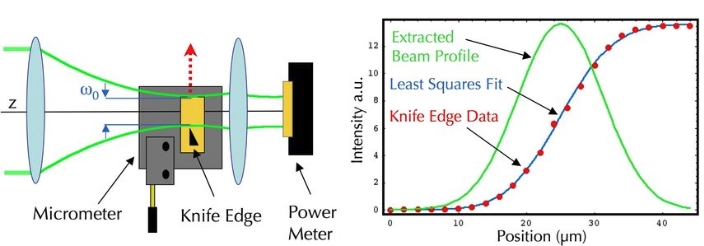

Import the numerical and graphing libraries that will be neeed.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit

Enter the collected data starting with the highest intensity
the distance array is entered in actual measurement units
the power array is normalized to the maximum power

In [ ]:
# Replace the values in rawPower with the ones that you collected
rawPower = np.array([1.167,1.165,1.164,1.162,1.157,1.151,1.136,1.105,1.033,.91,.73,.56,.42,.25,.145,.084,.055,.041,.032,.028,.026,.025,.024])

# Replace the values in distance with your start value, end value, and how many steps or measurements
distance = np.linspace(6.0,3.8,23)

power = rawPower / np.max(rawPower)
print(np.c_[distance, rawPower, power])


Create a function that returns the gaussian cumulative distribution function to use for curve fitting

In [ ]:
def gaussian_cdf(x, mean, stddev):
    return stats.norm.cdf(x, loc=mean, scale=stddev)

Run the curve fitting routine with an initial guess of mean and standard deviation. Next extract the fitted mean and standard deviation

In [ ]:
params, covariance = curve_fit(gaussian_cdf, distance, power, p0=[0, 1])
fitted_mean, fitted_stddev = params
print(f"Fitted mean: {fitted_mean}, Fitted stddev: {fitted_stddev}")

Lets now plot the collected data (normalized) and the fitted CFD

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(distance, power, 'bo', label='Observed data', markersize=5)
plt.plot(distance, gaussian_cdf(distance, *params), 'r-', label=f'Fitted CDF')
plt.xlabel('Distance')
plt.ylabel('CDF')
plt.title('Fitting CDF')
plt.legend()
plt.grid(True)
plt.show()

The above is only the Cumulative Probability Funciton, we can now find the Gaussian by reversing the "integration" using a derivative or gradient.

In [ ]:
beamProfile = np.gradient(gaussian_cdf(distance, *params),distance)

plt.figure(figsize=(8, 6))
plt.plot(distance, power, 'bo', label='Observed data', markersize=5)
plt.plot(distance, gaussian_cdf(distance, *params), 'r-', label=f'Fitted CDF')
plt.plot(distance, beamProfile,'g-',label=f'Beam Profile')
plt.xlabel('Distance')
plt.ylabel('Magnitude')
plt.title('Fitting CDF and PDF of Gaussian Beam Profile')
plt.legend()
plt.grid(True)
plt.show()

Create a finer resolution distance for plotting. distanceFine should match distance above, but with 4x more points

In [ ]:
distanceFine = np.linspace(6,3.8,92)
beamProfileFine = np.gradient(gaussian_cdf(distanceFine, *params),distanceFine)

In [ ]:
beamMean, beamStd = np.mean(beamProfileFine), np.std(beamProfileFine)
print(f"Beam Profile mean: {beamMean}, Beam Profile stddev: {beamStd}")

Then we plot all the data together

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(distance, power, 'bo', label='Observed data', markersize=5)
plt.plot(distance, gaussian_cdf(distance, *params), 'r-', label=f'Fitted CDF')
plt.plot(distance, beamProfile,'g-',label=f'Beam Profile')
plt.plot(distanceFine, beamProfileFine,'m-',label=f'Beam Profile (finer)') # This is the derivative of the fitted curve.
plt.xlabel('Distance')
plt.ylabel('Magnitude')
plt.title('Fitting CDF and PDF of Gaussian Distribution')
plt.legend()
plt.grid(True)
plt.show()
